# Predicting Maintenance Labor Hours for University Work Orders

**B104C Artificial Intelligence & Machine Learning - Individual Project**

### **Can information available when a maintenance work order starts help estimate its required labor effort accurately enough to support a university's workload planning?**

A facility manager of a university needs to plan and allocate workers to individual jobs. Overestimating labor effort can leave capacity unused, understimation is even worse as it can disrupt schedules. For the predictions/evaluation I will focus on individual jobs. 

The dataset that is used is the Facility Management Unified Classification Database (FMUCD), version 1, which was collected from facilities managers in Excel workbooks and standardised for publication. Each record stores one planned preventive or unplanned maintenance work order from twelve North American Universities. The target feature 'LaborHours' is the sum of time that the workers have spent working on the job, not the time between start and finish of the work order (Pampana et al. 2024a, 2024b). For this analysis I only use data from University 1 to keep the setting consistent.

Building size, age and use describe the setting, priority and system/subsystem describe the work, while start month captures possible seasonal variation. All features are available at work-order start.

After cleaning and initial data exploration, I compare linear regression and KNN, test if PCA or a log target improve the result and select a model and its hyperparameters using validation results. K-means is used as an unsupervised model for further exploration before getting to a final assessment and recommendation.


## 1. Load and clean

As the dataset is quite large the rows are loaded in chunks, keeping only University 1, to be faster and memory efficient. 

I remove exact duplicates and ambiguous repeated work-order IDs. The rows of the kept columns are stripped, blank strings become missing, the start date and numerical columns are parsed and incomplete rows are dropped.

Then only the records are used that have: a positive building size, a positive whole-valued construction year that's no later than the work-order start, a positive amount of labor and a system/subsystem description that's not "Unclassified". 

The building age and start month features are derived from the start date and built year. Size means the building area in gross square feet and Type describes what the building is used for. Work-order-id (WOID) is just used for data cleaning and not used as a feature later. The description text is omitted as NLP would be necessary and other columns like cost or duration are excluded to avoid data leakage.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

data_path = Path("data") / "Facility Management Unified Classification Database (FMUCD).csv"
parts = []
for chunk in pd.read_csv(data_path, dtype=str, keep_default_na=False,
                         chunksize=100_000):
    parts.append(chunk.loc[chunk["UniversityID"].eq("1")])

df = pd.concat(parts, ignore_index=True)
del parts, chunk
row_counts = [("Source University 1", len(df))]

df = df.drop_duplicates().copy()
row_counts.append(("After exact duplicates", len(df)))
df = df.loc[~df["WOID"].duplicated(keep=False)].copy()
row_counts.append(("After repeated-ID removal", len(df)))

In [2]:
columns = [
    "WOID", "WOStartDate", "Size", "Type", "BuiltYear", "WOPriority",
    "SystemDescription", "SubsystemDescription", "LaborHours",
]
df = df[columns].copy()
for column in df.columns:
    df[column] = df[column].str.strip()
df = df.replace("", np.nan)

df["WOStartDate"] = pd.to_datetime(
    df["WOStartDate"], errors="coerce", format="%Y-%m-%d %H:%M:%S"
)
for column in ["Size", "BuiltYear", "LaborHours"]:
    df[column] = pd.to_numeric(df[column], errors="coerce").replace(
        [np.inf, -np.inf], np.nan
    )

df = df.dropna().copy()
row_counts.append(("After missing values", len(df)))

In [3]:
valid = (
    df["Size"].gt(0)
    & df["BuiltYear"].gt(0)
    & df["BuiltYear"].mod(1).eq(0)
    & df["BuiltYear"].le(df["WOStartDate"].dt.year)
    & df["LaborHours"].gt(0)
)
df = df.loc[valid].copy()
row_counts.append(("After invalid and zero values", len(df)))

df = df.loc[
    df["SystemDescription"].ne("Unclassified")
    & df["SubsystemDescription"].ne("Unclassified")
].copy()
row_counts.append(("After unclassified values", len(df)))

df["BuildingAge"] = df["WOStartDate"].dt.year - df["BuiltYear"]
df["WOStartMonth"] = df["WOStartDate"].dt.month.astype(str)
df_clean = df.reset_index(drop=True)

display(pd.DataFrame(row_counts, columns=["Stage", "Rows"]))
df_clean.head()

,Stage,Rows
0,Source University 1,138253
1,After exact duplicates,138175
2,After repeated-ID removal,134038
3,After missing values,128360
4,After invalid and zero values,118568
5,After unclassified values,118406


,WOID,WOStartDate,Size,Type,BuiltYear,WOPriority,SystemDescription,SubsystemDescription,LaborHours,BuildingAge,WOStartMonth
0,WO244376,2012-12-17 07:49:05,5529.0,Research,1942.0,3,Plumbing,Domestic Water Distribution,3.0,70.0,12
1,WO247428,2013-01-15 09:05:33,30619.0,Student Experience,1963.0,30,Interior Finishes,Wall Finishes,19.5,50.0,1
2,WO248110,2013-01-21 09:42:39,161395.0,Mixed Teaching/Research,1971.0,2,HVAC,Distribution Systems,0.5,42.0,1
3,WO249443,2013-01-29 09:27:12,4405.0,Research,1850.0,3,HVAC,Distribution Systems,0.5,163.0,1
4,WO250777,2013-02-07 15:02:04,107080.0,Mixed Teaching/Research,1971.0,1,HVAC,Controls and Instrumentation,1.0,42.0,2


Cleaning retains 118,406 of the 138,253 University 1 records. The data can now be safely split, but conclusions apply only to this filtered group.

## 2. Split the data

I use a fixed 60/20/20 random split for training, validation (selecting an algorithm and tuning the hyperparameters) and test (to assess the specific selected model/settings), with random_state=42 to keep the results reproducible. For the specific question I chose to not use a chronological split and as buildings can occur across sets the results will be an assessment of similar work orders at the same university but don't demonstrate performance on unfamiliar buildings or future years.

In [4]:
from sklearn.model_selection import train_test_split

numeric_features = ["Size", "BuildingAge"]
categorical_features = [
    "WOPriority", "WOStartMonth", "Type",
    "SystemDescription", "SubsystemDescription",
]
features = numeric_features + categorical_features

df_development, df_test = train_test_split(
    df_clean, test_size=0.20, random_state=42
)
df_train, df_valid = train_test_split(
    df_development, test_size=0.25, random_state=42
)

X_train, y_train = df_train[features], df_train["LaborHours"]
X_valid, y_valid = df_valid[features], df_valid["LaborHours"]
X_test, y_test = df_test[features], df_test["LaborHours"]

pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(df_train), len(df_valid), len(df_test)],
})

,Split,Rows
0,Train,71043
1,Validation,23681
2,Test,23682


## 3. Explore the training data

Next I explore the training data to learn about distribution and model needs as well as checking ranges and labor by system. The histogram shows the target distribution using a log-transformed target variable to make the large range easier to display. Balancing is not needed here as this is regression using a continous target.

In [5]:
display(
    df_train[["LaborHours", "Size", "BuildingAge"]]
    .describe(percentiles=[0.5, 0.9, 0.99]).T
)
display(
    df_train.groupby("SystemDescription")["LaborHours"]
    .agg(count="size", median="median")
    .sort_values("count", ascending=False)
    .head(8)
)

,count,mean,std,min,50%,90%,99%,max
LaborHours,71043.0,4.304599,43.132790,0.25,2.0,6.0,28.5,7526.0
Size,71043.0,107251.623017,97127.575106,300.00,80463.0,206879.0,379218.0,379218.0
BuildingAge,71043.0,54.713934,32.539207,0.00,50.0,104.0,142.0,169.0


,count,median
SystemDescription,,
Electrical,17277,2.0
Plumbing,16383,2.0
HVAC,15820,2.0
Fire Protection,9285,1.5
Interior Construction,4523,2.0
Interior Finishes,2541,2.0
General,1247,1.0
Equipment,1230,1.0


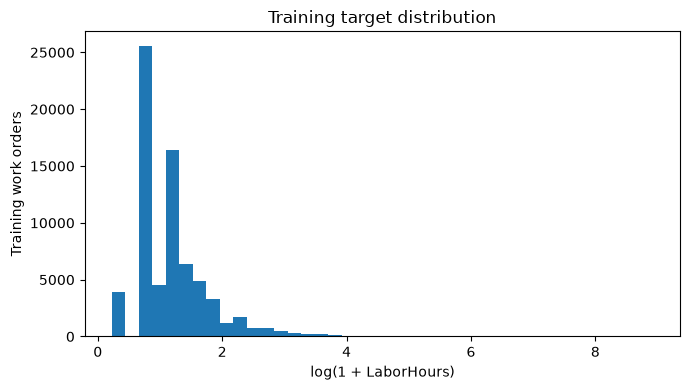

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(np.log1p(y_train), bins=40)
plt.xlabel("log(1 + LaborHours)")
plt.ylabel("Training work orders")
plt.title("Training target distribution")
plt.tight_layout()
plt.show()

The median is 2 hours and 90% of jobs take 6 labor hours or less, while the maximum is 7,526. This motivates MAE alongside RMSE for evaluation and a log-target comparison due to the few high values. Size and age also need scaling for distance-based methods.

## 4. Preprocess predictors and set baselines

During preprocessing building size and age are standardized to prevent their units dominating distances. The other categorical features are one-hot-encoded, including WOPriority as there was no clear or verifiable order or spacing. Preprocessing is only fitted on training data here to prevent (indirect) leakage.

The primary selection metric is MAE (in hours) as it shows the mean absolute difference between predicted and actual labor which is most important for planning. Square root of mean squared error (RMSE) is used to penalise large errors more strongly. R² compares squared prediction error with predicting the evaluation-set mean. A negative mean error means underestimation and leads to scheduling risks which are further investigated though frequency and shortfall. Total-hours error is also calculated but opposite individual errors cancel each other out.

As a baseline I use the training median that should minimise MAE and training mean that should minimise RMSE. They are constant for every job and don't use the jobs predictors.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     categorical_features),
])
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
print("Features before one-hot encoding:", X_train.shape[1])
print("Features after one-hot encoding:", X_train_processed.shape[1])

def regression_metrics(actual, predicted):
    errors = np.asarray(predicted) - np.asarray(actual)
    underestimated = errors < -1e-9  # Ignore tiny rounding differences around zero.
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
        "Mean error (hours)": errors.mean(),
        "Underestimated jobs (%)": 100 * underestimated.mean(),
        "Mean shortfall when underestimated (hours)": (
            -errors[underestimated].mean() if underestimated.any() else 0.0
        ),
        "Total hours error (%)": 100 * (predicted.sum() / actual.sum() - 1),
    }

baseline_rows = {}
for label, strategy in [("Median baseline", "median"),
                        ("Mean baseline", "mean")]:
    model = DummyRegressor(strategy=strategy).fit(X_train_processed, y_train)
    baseline_rows[label] = regression_metrics(
        y_valid, model.predict(X_valid_processed)
    )
print("Validation baselines — MAE and RMSE in hours")
pd.DataFrame(baseline_rows).T[[
    "MAE", "RMSE", "Mean error (hours)", "Total hours error (%)"
]].round(3)

Features before one-hot encoding: 7
Features after one-hot encoding: 98
Validation baselines — MAE and RMSE in hours


,MAE,RMSE,Mean error (hours),Total hours error (%)
Median baseline,3.609,36.851,-2.651,-56.996
Mean baseline,4.807,36.757,-0.346,-7.442


As expected the median has a lower MAE and will therefore be the main benchmark for the supervised models. The mean has a lower RMSE and total hours error and is useful as a benchmark for total prediction accuracy.

## 5. Compare linear regression and KNN

For supervised learning I use linear regression which models additive relationship and K-nearest-neighbours which averages nearby examples. In KNN a small k-value is more sensitive to individual records, while large values smooth predictions and may miss local differences. I compare several values on validation data and clip negative predictions to zero as labor hours can't be negative. Timing is also examined and does not include preprocessing.

In [8]:
from time import perf_counter
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

model_specs = {"Linear regression": LinearRegression()}
knn_k_values = [1, 2, 3, 4, 5, 6, 7, 8, 15, 31]
model_specs.update({
    f"KNN k={k}": KNeighborsRegressor(n_neighbors=k)
    for k in knn_k_values
})
results = []

for name, model in model_specs.items():
    fitted = clone(model)
    started = perf_counter()
    fitted.fit(X_train_processed, y_train)
    predicted = np.maximum(fitted.predict(X_valid_processed), 0)
    seconds = perf_counter() - started
    metrics = regression_metrics(y_valid, predicted)
    results.append({"Model": name, "Features": "Original", "Target": "Raw",
                    **metrics, "Seconds": seconds})

original_raw_results = pd.DataFrame(results).sort_values(["MAE", "RMSE"])
print("Original features, raw target — validation MAE and RMSE in hours")
original_raw_results[[
    "Model", "MAE", "RMSE", "Mean error (hours)",
    "Total hours error (%)", "Seconds",
]].round(3)

Original features, raw target — validation MAE and RMSE in hours


,Model,MAE,RMSE,Mean error (hours),Total hours error (%),Seconds
1,KNN k=1,3.549,27.711,0.050,1.065,2.910
2,KNN k=2,3.618,26.463,0.109,2.353,2.868
3,KNN k=3,3.766,27.597,0.151,3.240,3.164
4,KNN k=4,3.844,27.689,0.031,0.656,2.727
5,KNN k=5,3.948,28.588,-0.068,-1.471,2.596
10,KNN k=31,3.955,26.974,-0.256,-5.512,2.652
6,KNN k=6,4.008,29.209,-0.151,-3.253,2.694
7,KNN k=7,4.055,29.361,-0.221,-4.757,2.679
8,KNN k=8,4.081,29.568,-0.301,-6.482,2.573
9,KNN k=15,4.110,29.689,-0.461,-9.903,2.638


Raw KNN k=1 has the lowest MAE but only slightly improves on the median baseline. k=2 has the lowest RMSE. Linear regression is worse on MAE and RMSE, but performs better on time.

## 6. Compare models with PCA

Next I test if feature reduction using PCA can improve the results, since one-hot-encoding expanded the number of features from 7 to 98. The PCA retains 95% of training-input variance and is again fitted only on the training data. Then I repeat the same evaluation and compare the results.

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, svd_solver="full")
X_train_pca = pca.fit_transform(X_train_processed)
X_valid_pca = pca.transform(X_valid_processed)
print("Dimensions:", X_train_processed.shape[1], "->", X_train_pca.shape[1])
print("Variance retained:", pca.explained_variance_ratio_.sum(), "\n")

for name, model in model_specs.items():
    fitted = clone(model)
    started = perf_counter()
    fitted.fit(X_train_pca, y_train)
    predicted = np.maximum(fitted.predict(X_valid_pca), 0)
    seconds = perf_counter() - started
    results.append({"Model": name, "Features": "PCA", "Target": "Raw",
                    **regression_metrics(y_valid, predicted),
                    "Seconds": seconds})

raw_results = pd.DataFrame(results)
for title, metric in [
    ("Validation MAE (hours)", "MAE"),
    ("Validation RMSE (hours)", "RMSE"),
    ("Fit + predict time (seconds)", "Seconds"),
]:
    print(title)
    display(
        raw_results[["Model", "Features", metric]]
        .sort_values(metric)
        .reset_index(drop=True)
        .round(3)
    )

Dimensions: 98 -> 33
Variance retained: 0.9506322348947186 

Validation MAE (hours)


,Model,Features,MAE
0,KNN k=1,Original,3.549
1,KNN k=2,Original,3.618
2,KNN k=1,PCA,3.627
3,KNN k=2,PCA,3.677
4,KNN k=3,Original,3.766
5,KNN k=4,Original,3.844
6,KNN k=3,PCA,3.845
7,KNN k=5,Original,3.948
8,KNN k=31,Original,3.955
9,KNN k=6,Original,4.008


Validation RMSE (hours)


,Model,Features,RMSE
0,KNN k=2,Original,26.463
1,KNN k=2,PCA,26.877
2,KNN k=31,Original,26.974
3,KNN k=1,PCA,27.570
4,KNN k=3,Original,27.597
5,KNN k=4,Original,27.689
6,KNN k=1,Original,27.711
7,KNN k=3,PCA,28.221
8,KNN k=5,Original,28.588
9,KNN k=6,Original,29.209


Fit + predict time (seconds)


,Model,Features,Seconds
0,Linear regression,PCA,0.057
1,Linear regression,Original,0.238
2,KNN k=3,PCA,1.590
3,KNN k=1,PCA,1.599
4,KNN k=5,PCA,1.608
5,KNN k=4,PCA,1.621
6,KNN k=2,PCA,1.641
7,KNN k=15,PCA,1.649
8,KNN k=31,PCA,1.721
9,KNN k=8,PCA,1.787


PCA reduced 98 features to 33 and speeds up fitting and prediction, but worsened every raw KNN MAE. Linear regression improved only slightly, staying behind KNN.

## 7. Test a log-transformed target

In the next step I explore if fitting the same models to a log-transformed target (log1p(y), meaning log(1+y)) could improve results by reducing the influence of large values. expm1 is the reverse used to convert the predictions back to hours before evaluation so they are comparable with previous results.

In [10]:
for representation, train_matrix, valid_matrix in [
    ("Original", X_train_processed, X_valid_processed),
    ("PCA", X_train_pca, X_valid_pca),
]:
    for name, model in model_specs.items():
        fitted = clone(model)
        started = perf_counter()
        fitted.fit(train_matrix, np.log1p(y_train))
        predicted = np.maximum(np.expm1(fitted.predict(valid_matrix)), 0)
        seconds = perf_counter() - started
        metrics = regression_metrics(y_valid, predicted)
        results.append({"Model": name, "Features": representation, "Target": "Log1p",
                        **metrics, "Seconds": seconds})

results_df = (
    pd.DataFrame(results)
    .sort_values(["MAE", "RMSE"])
    .reset_index(drop=True)
)
print("Validation MAE (hours) — lower is better")
display(results_df.pivot(
    index="Model", columns=["Target", "Features"], values="MAE"
).sort_values(('Log1p', 'Original')).round(3))

Validation MAE (hours) — lower is better


Target               Log1p             Raw       
Features          Original    PCA Original    PCA
Model                                            
KNN k=2              3.220  3.306    3.618  3.677
KNN k=3              3.355  3.499    3.766  3.845
KNN k=31             3.376  3.458    3.955  4.501
KNN k=4              3.455  3.578    3.844  4.017
KNN k=15             3.461  3.550    4.110  4.475
KNN k=7              3.472  3.599    4.055  4.255
KNN k=6              3.482  3.606    4.008  4.209
KNN k=8              3.483  3.596    4.081  4.323
KNN k=5              3.490  3.599    3.948  4.119
KNN k=1              3.549  3.627    3.549  3.627
Linear regression    3.581  3.616    5.638  5.610

The log target improves MAE for all models except k=1, since with one neighbour, converting its logged value back gives the original labor value. For larger k, averaging logs changes the prediction and reduces the influence of high-hour neighbours leading to better scores.

## 8. Select the model

For the final model selection I summarise the leading log-target setting, its PCA version, the leading raw-target KNN and the median baseline.

In [11]:
selection_table = results_df.loc[
    ((results_df["Model"] == "KNN k=1")
     & (results_df["Features"] == "Original") & (results_df["Target"] == "Raw"))
    | ((results_df["Model"] == "KNN k=2") & (results_df["Target"] == "Log1p")),
    ["Model", "Features", "Target", "MAE", "RMSE"],
].reset_index(drop=True)
selection_table.loc[len(selection_table)] = [
    "Median baseline", "—", "Raw",
    baseline_rows["Median baseline"]["MAE"], baseline_rows["Median baseline"]["RMSE"],
]
print("Validation comparison — MAE and RMSE in hours")
display(selection_table.sort_values("MAE").reset_index(drop=True).round(3))

Validation comparison — MAE and RMSE in hours


,Model,Features,Target,MAE,RMSE
0,KNN k=2,Original,Log1p,3.220,28.086
1,KNN k=2,PCA,Log1p,3.306,29.299
2,KNN k=1,Original,Raw,3.549,27.711
3,Median baseline,—,Raw,3.609,36.851


I select log-target KNN k=2 without PCA as it has the lowest validation MAE: 3.220 hours versus 3.609 for the median. Raw k=1 has slightly better RMSE but worse MAE, and PCA worsens the selected setting. This follows the stated priority of predicting individual jobs, rather than total-hours-error or RMSE.

Now that I have selected a model, I create a pipeline to combine preprocessing and the selected KNN model. The "TransformedTargetRegressor" is used to apply "log1p" during fitting and then reverse the predictions using "expm1". For now it is fitted only on the training data.

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor

selected_name = "Log-target KNN k=2"
selected_model = TransformedTargetRegressor(
    regressor=make_pipeline(
        clone(preprocessor), KNeighborsRegressor(n_neighbors=2)
    ),
    func=np.log1p,
    inverse_func=np.expm1,
)
selected_model.fit(X_train, y_train)
print(selected_name)
selected_model

Log-target KNN k=2


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...eighbors=2))])
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Size','BuildingAge','WOPriority',...,'Type','SystemDescription', 'SubsystemDescription']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,7
regressor_ regressor_: objectFitted regressor.,Pipeline,Pipeline(step...eighbors=2))])
transformer_ transformer_: objectTransformer used in :meth:`fit` and :meth:`predict`.,FunctionTransformer,FunctionTrans...validate=True)
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('kneighborsregressor', ...)]"


## 9. Examine informative features

Last but not least for supervised learning I was interested in finding out which feature is most important for the prediction. Since KNN has no coefficients to rank I shuffle each feature on 2,000 fixed validation rows three times. A larger MAE increase suggests greater reliance on that feature.

In [13]:
from sklearn.inspection import permutation_importance

X_explain = X_valid.sample(n=2000, random_state=42)
y_explain = y_valid.loc[X_explain.index]
importance = permutation_importance(
    selected_model, X_explain, y_explain,
    scoring="neg_mean_absolute_error", n_repeats=3, random_state=42,
)
importance_table = pd.DataFrame({
    "Feature": features,
    "MAE increase (hours)": importance.importances_mean,
    "Shuffle SD": importance.importances_std,
}).sort_values("MAE increase (hours)", ascending=False)
importance_table.round(3)

,Feature,MAE increase (hours),Shuffle SD
6,SubsystemDescription,1.797,0.603
5,SystemDescription,1.642,0.463
4,Type,1.176,0.365
2,WOPriority,1.105,0.107
0,Size,1.099,0.293
1,BuildingAge,0.789,0.512
3,WOStartMonth,0.481,0.097


Subsystem and system description seem to have the largest effect on the MAE, but they also contain related information. Type and Priority come right after. Even though it's interesting to see, these results show model reliance rather than causal effects on labor hours.

## 10. Explore groups with K-means

For unsupervised learning I examine if there are interpretable groups of work orders with similar building and work characteristics. I use K-means which groups records by distance to cluster centers. The inputs are almost the same, though labor and IDs are excluded as well as month to focus on the work setting. Numerical features are scaled and categorical features are one-hot-encoded again. K values of 2 to 6 are compared using inertia (measures within-cluster squared distance) and silhouette score (compares within-group distance with separation from other groups).

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_categorical = [
    "WOPriority", "Type", "SystemDescription", "SubsystemDescription"
]
cluster_features = numeric_features + cluster_categorical
cluster_preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     cluster_categorical),
])
X_cluster = cluster_preprocessor.fit_transform(df_train[cluster_features])

cluster_rows, kmeans_models = [], {}
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_cluster)
    cluster_rows.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(
            X_cluster, labels, sample_size=2000, random_state=42
        ),
        "Smallest cluster": pd.Series(labels).value_counts().min(),
    })
    kmeans_models[k] = model
cluster_results = pd.DataFrame(cluster_rows)
cluster_results.round(3)

,k,Inertia,Silhouette,Smallest cluster
0,2,304485.915,0.162,34455
1,3,268328.636,0.155,14711
2,4,251038.500,0.127,14711
3,5,237944.517,0.131,6723
4,6,229238.117,0.128,4500


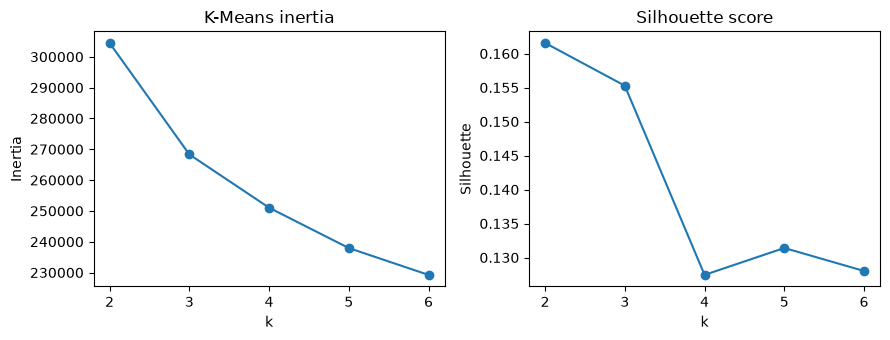

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(cluster_results["k"], cluster_results["Inertia"], marker="o")
axes[0].set(xlabel="k", ylabel="Inertia", title="K-Means inertia")
axes[1].plot(cluster_results["k"], cluster_results["Silhouette"], marker="o")
axes[1].set(xlabel="k", ylabel="Silhouette", title="Silhouette score")
plt.tight_layout()
plt.show()

Inertia falls (improves) with more clusters displaying an elbow point at k=3. The silhouette score worsens slightly from k=2 to k=3 and then rapidly with k=4. 

In the next step I will compare k=2 and k=3 before selecting a final k-value. Labor is added only to describe groups after clustering.

In [16]:
for k in [2, 3]:
    print(f"k = {k}")
    clustered = df_train.copy()
    clustered["Cluster"] = kmeans_models[k].labels_
    cluster_profiles = clustered.groupby("Cluster").agg(
        Orders=("WOID", "size"), Median_size_GSF=("Size", "median"),
        Median_building_age=("BuildingAge", "median"),
        Median_labor_hours=("LaborHours", "median"),
    )
    display(cluster_profiles.round(2))
    display(pd.crosstab(clustered["Cluster"], clustered["Type"],
                        normalize="index").round(3))

k = 2


,Orders,Median_size_GSF,Median_building_age,Median_labor_hours
Cluster,,,,
0,34455,159333.0,45.0,2.0
1,36588,31440.0,64.0,1.5


Type,Mixed Teaching/Research,Other,Research,Student Experience,Teaching
Cluster,,,,,
0,0.512,0.002,0.081,0.168,0.238
1,0.147,0.307,0.030,0.177,0.339


k = 3


,Orders,Median_size_GSF,Median_building_age,Median_labor_hours
Cluster,,,,
0,39441,89991.0,45.0,2.0
1,16891,20843.0,97.0,1.0
2,14711,206879.0,49.0,2.0


Type,Mixed Teaching/Research,Other,Research,Student Experience,Teaching
Cluster,,,,,
0,0.185,0.162,0.080,0.248,0.325
1,0.191,0.292,0.041,0.146,0.330
2,0.849,0.000,0.000,0.000,0.151


I choose k=3 because inertia falls 11.9% from k=2, compared with 6.4% at the next step, while the silhouette score changes from 0.162 to 0.155 (before dropping to 0.127). The profiles distinguish medium-sized, small older and large buildings. The last group is mainly mixed teaching/research. Separation is weak and buildings with more orders have more influence.

## 11. Assess the selected (supervised) model

Finally I refit the previously chosen specification on combined training and validation data to use the maximum available data without causing leakage. Then I assess the test predictions and compare them with the baseline and raw KNN alternatives.

In [17]:
df_development = pd.concat([df_train, df_valid])
X_development = df_development[features]
y_development = df_development["LaborHours"]

test_models = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Raw KNN k=1": make_pipeline(
        clone(preprocessor), KNeighborsRegressor(n_neighbors=1)
    ),
    "Raw KNN k=2": make_pipeline(
        clone(preprocessor), KNeighborsRegressor(n_neighbors=2)
    ),
    selected_name: clone(selected_model),
}
test_rows, test_predictions = {}, {}
for name, model in test_models.items():
    model.fit(X_development, y_development)
    predicted = np.maximum(model.predict(X_test), 0)
    test_predictions[name] = predicted
    test_rows[name] = {
        **regression_metrics(y_test, predicted),
        "Actual total (hours)": y_test.sum(),
        "Predicted total (hours)": predicted.sum(),
    }

test_results = pd.DataFrame(test_rows).T
print("Individual-job accuracy — MAE and RMSE in hours")
display(test_results[["MAE", "RMSE", "R2"]].sort_values("MAE").round(3))
print("Practical underestimation checks")
display(test_results[[
    "Mean error (hours)", "Underestimated jobs (%)",
    "Mean shortfall when underestimated (hours)",
]].round(3))
print("Supporting total-hours measures")
display(test_results[[
    "Actual total (hours)", "Predicted total (hours)", "Total hours error (%)",
]].round(3))

Individual-job accuracy — MAE and RMSE in hours


,MAE,RMSE,R2
Log-target KNN k=2,2.845,22.308,0.597
Raw KNN k=2,3.162,21.301,0.632
Median baseline,3.366,35.204,-0.005
Raw KNN k=1,3.581,30.160,0.263
Mean baseline,4.620,35.122,-0.000


Practical underestimation checks


,Mean error (hours),Underestimated jobs (%),Mean shortfall when underestimated (hours)
Median baseline,-2.412,31.855,9.070
Mean baseline,-0.021,14.146,16.406
Raw KNN k=1,-0.095,34.469,5.333
Raw KNN k=2,-0.099,35.449,4.599
Log-target KNN k=2,-0.763,39.047,4.620


Supporting total-hours measures


,Actual total (hours),Predicted total (hours),Total hours error (%)
Median baseline,104488.0,47364.000,-54.670
Mean baseline,104488.0,103990.624,-0.476
Raw KNN k=1,104488.0,102229.480,-2.162
Raw KNN k=2,104488.0,102155.090,-2.233
Log-target KNN k=2,104488.0,86426.386,-17.286


The selected model has the lowest test MAE, but raw k=2 has lower RMSE. R² of 0.597 describes reduced squared error relative to the test mean. The large MAE/RMSE gap led me to checking errors by job size.

So the last evaluation compares three labor bands: up to two hours (the training median), between two and eight hours (using eight hours as an illustrative working-day threshold) and over eight hours. Since actual labor hours are only known after a job is finished these bands cannot select a model for a new job.

In [18]:
band_tables = []
for name in ["Median baseline", "Raw KNN k=2", selected_name]:
    errors = pd.DataFrame({"Actual": y_test, "Predicted": test_predictions[name]})
    errors["Error"] = errors["Predicted"] - errors["Actual"]
    errors["Absolute error"] = errors["Error"].abs()
    errors["Squared error"] = errors["Error"] ** 2
    errors["Underestimated (%)"] = 100 * errors["Error"].lt(-1e-9)
    errors["Actual labor band"] = pd.cut(
        errors["Actual"], bins=[0, 2, 8, np.inf],
        labels=["Up to 2 hours", "Over 2 to 8 hours", "Over 8 hours"],
    )
    table = errors.groupby("Actual labor band", observed=True).agg(
        Orders=("Actual", "size"),
        MAE_hours=("Absolute error", "mean"),
        MSE_hours_squared=("Squared error", "mean"),
        Mean_error_hours=("Error", "mean"),
        Underestimated_pct=("Underestimated (%)", "mean"),
    )
    table["RMSE_hours"] = np.sqrt(table.pop("MSE_hours_squared"))
    table["Model"] = name
    band_tables.append(table.reset_index())
error_summary = pd.concat(band_tables, ignore_index=True)
display(error_summary[[
    "Model", "Actual labor band", "Orders", "MAE_hours", "RMSE_hours",
    "Mean_error_hours", "Underestimated_pct",
]].round(3))

,Model,Actual labor band,Orders,MAE_hours,RMSE_hours,Mean_error_hours,Underestimated_pct
0,Median baseline,Up to 2 hours,16138,0.700,0.859,0.700,0.000
1,Median baseline,Over 2 to 8 hours,6152,2.119,2.553,-2.119,100.000
2,Median baseline,Over 8 hours,1392,39.789,145.078,-39.789,100.000
3,Raw KNN k=2,Up to 2 hours,16138,1.521,10.486,1.312,17.462
4,Raw KNN k=2,Over 2 to 8 hours,6152,2.737,13.965,-0.311,69.945
5,Raw KNN k=2,Over 8 hours,1392,24.063,74.717,-15.512,91.523
6,Log-target KNN k=2,Up to 2 hours,16138,1.122,7.743,0.898,20.275
7,Log-target KNN k=2,Over 2 to 8 hours,6152,2.346,11.244,-0.934,75.650
8,Log-target KNN k=2,Over 8 hours,1392,25.037,84.929,-19.255,94.899


## 12. Discussion and recommendation

The selected log-target KNN k=2 without PCA has a test MAE of 2.845 hours, compared with 3.366 for the median baseline. Predictions are therefore closer to actual labor by about half an hour per job on average, but the improvement is not consistent across labor bands.

The median performs better in both smaller labor bands, while KNN improves predictions for jobs requiring more than eight labor hours. However, the selected model still has an MAE of 25.04 hours in this largest band and underestimates 94.9% of these jobs, making individual estimates almost impossible to rely on for planning/allocating workers. The labor bands explain these differences but cannot help with model selction for new orders, since actual labor is unknown at the start of the work-order.

The pipeline compares linear regression and KNN against a baseline and then uses validation results to select the best settings. For the KNN model system and subsystem descriptions appear to be the most informative features. KNN estimates from similar recorded jobs, but using only two neighbours makes predictions sensitive to individual records. Additionally the relatively small sample of filtered data from one university further limits conclusions about future work. The results of K-means also aren't convincing, showing weak separation, so I would not use its groups for staffing decisions.

I would first test the estimates alongside the planner’s judgement on new orders, recording inputs at job start and labor after completion, but I would not allocate workers automatically from the current predictions. The planner should define acceptable errors for individual jobs, especially where underestimation could disrupt schedules.

## References

- Pampana, A.K., Jeon, J., Yoon, S. and Weidner, T.J. (2024a) 'Comprehensive maintenance dataset of building facilities for planned preventive and unplanned maintenance in North American universities', *Data in Brief*, 57, 110845. [Article](https://pmc.ncbi.nlm.nih.gov/articles/PMC11465139/).
- Pampana, A.K., Jeon, J., Yoon, S. and Weidner, T. (2024b) *Facility Management Unified Classification Database (FMUCD)*, version 1. Mendeley Data. DOI: 10.17632/cb8d2nsjss.1. CC BY 4.0. [Dataset](https://data.mendeley.com/datasets/cb8d2nsjss/1).
- Scikit-learn developers (n.d.) *Scikit-learn documentation*: [KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html), [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [target transformation](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html), [permutation importance](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html). Accessed 16 September 2026.